# Phase 5A: Pretrained ResNet-50 CNN Baseline
### Automated Classification of Martian Surface Images Captured by NASA's Curiosity Rover Using Machine Learning

---

## 1. Executive Summary & Objective

In Phase 4B, classical machine learning models trained on 8,186 handcrafted visual features (HOG, GLCM, color moments, edge/texture statistics) achieved a champion test accuracy of **47.20%** and test Macro-F1 of **0.5407** (KNN-4 with PCA-100 and distance weighting).

**Phase 5A establishes our first deep-learning baseline** using a pretrained ResNet-50 Convolutional Neural Network (CNN). Key principles:
1. **Direct Raw Image Pixels**: We bypass all handcrafted features and feed preprocessed images directly to the neural network.
2. **Aspect-Ratio-Preserving Letterboxing**: Images are resized to $224 \times 224$ with constant padding, preserving 100% of geological structures and rover parts without distortion or cropping.
3. **Zero Data Leakage**: Class weights, preprocessing, and model selection are strictly derived from the official training split (3,746 images).
4. **Strict Checkpoint Selection**: The best checkpoint is selected strictly based on **Validation Macro-F1** evaluated on the real validation set (1,640 images).
5. **Single-Pass Test Protocol**: The official test set (1,305 images) is evaluated **exactly once** after the final checkpoint is finalized.

In [1]:
import os
import sys
from pathlib import Path
import certifi
import json

# Ensure SSL certificates and project path
if 'SSL_CERT_FILE' not in os.environ:
    os.environ['SSL_CERT_FILE'] = certifi.where()

PROJECT_ROOT = Path('.').resolve().parent if Path('.').resolve().name == 'notebooks' else Path('.').resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import config
from deep_learning import (
    load_synset_mapping,
    load_split_records,
    build_active_class_mappings,
    compute_training_class_weights,
    get_eval_transforms,
    MarsRoverDataset,
    build_resnet50_baseline,
    get_device
)

print(f"PyTorch Version : {torch.__version__}")
device = get_device()
print(f"Active Device   : {device}")

PyTorch Version : 2.14.0
Active Device   : mps


## 2. Dataset Verification & Active Class Space

We load the official NASA Curiosity rover split files directly from `Mars rover data/`:

In [2]:
train_records = load_split_records(config.TRAIN_LABELS_PATH)
val_records = load_split_records(config.VAL_LABELS_PATH)
test_records = load_split_records(config.TEST_LABELS_PATH)

print(f"Train samples      : {len(train_records):,} (Expected: 3,746)")
print(f"Validation samples : {len(val_records):,} (Expected: 1,640)")
print(f"Test samples       : {len(test_records):,} (Expected: 1,305)")
print(f"Total images       : {len(train_records) + len(val_records) + len(test_records):,} (Expected: 6,691)")

assert len(train_records) == 3746
assert len(val_records) == 1640
assert len(test_records) == 1305

class_names = load_synset_mapping(config.CLASS_MAPPING_PATH)
orig_to_active, active_to_orig, active_to_name, active_classes = build_active_class_mappings(train_records, class_names)
print(f"\nActive classes     : {len(active_classes)} active classes (NASA IDs 0..21, 23, 24)")
print(f"Zero-sample class  : NASA ID 22 ('{class_names[22]}') correctly excluded from target space.")

Train samples      : 3,746 (Expected: 3,746)
Validation samples : 1,640 (Expected: 1,640)
Test samples       : 1,305 (Expected: 1,305)
Total images       : 6,691 (Expected: 6,691)

Active classes     : 24 active classes (NASA IDs 0..21, 23, 24)
Zero-sample class  : NASA ID 22 ('sun') correctly excluded from target space.


## 3. Training Class Distribution & Class Weights

We calculate the real class distribution from the training set and compute un-capped balanced class weights:

In [3]:
weights = compute_training_class_weights(train_records, orig_to_active)
train_labels = [orig_to_active[lbl] for _, lbl in train_records]
counts = pd.Series(train_labels).value_counts().sort_index()

dist_df = pd.DataFrame({
    'Active Index': range(24),
    'NASA ID': [active_to_orig[i] for i in range(24)],
    'Class Name': [active_to_name[i] for i in range(24)],
    'Train Count': [counts.get(i, 0) for i in range(24)],
    'Class Weight': [round(weights[i].item(), 4) for i in range(24)]
})
dist_df

,Active Index,NASA ID,Class Name,Train Count,Class Weight
0,0,0,apxs,30,5.2028
1,1,1,apxs cal target,6,26.0139
2,2,2,chemcam cal target,15,10.4056
3,3,3,chemin inlet open,47,3.3209
4,4,4,drill,19,8.2149
5,5,5,drill holes,36,4.3356
6,6,6,drt front,4,39.0208
7,7,7,drt side,8,19.5104
8,8,8,ground,2343,0.0666
9,9,9,horizon,224,0.6968


## 4. ResNet-50 Model Architecture

We inspect the pretrained ResNet-50 architecture and verify that the classification head has been modified to output exactly 24 logits:

In [4]:
model, meta = build_resnet50_baseline(num_classes=24, pretrained=True, dropout_rate=0.2)
print("Model Architecture Details:")
for k, v in meta.items():
    print(f"  • {k:<22}: {v}")

# Forward pass verification with dummy tensor (used strictly for verification)
dummy = torch.zeros(2, 3, 224, 224)
with torch.no_grad():
    out = model(dummy)
print(f"\nSanity check output shape: {out.shape} (Expected: (2, 24))")
assert out.shape == (2, 24)

Model Architecture Details:
  • architecture          : ResNet-50
  • pretrained            : True
  • checkpoint            : ResNet50_Weights.DEFAULT (IMAGENET1K_V1)
  • input_channels        : 3
  • input_resolution      : (224, 224)
  • in_features           : 2048
  • num_classes           : 24
  • dropout_rate          : 0.2
  • total_parameters      : 23557208
  • trainable_parameters  : 23557208

Sanity check output shape: torch.Size([2, 24]) (Expected: (2, 24))


## 5. Training History & Learning Curves

We load and visualize the training and validation telemetry generated during Phase 5A execution:

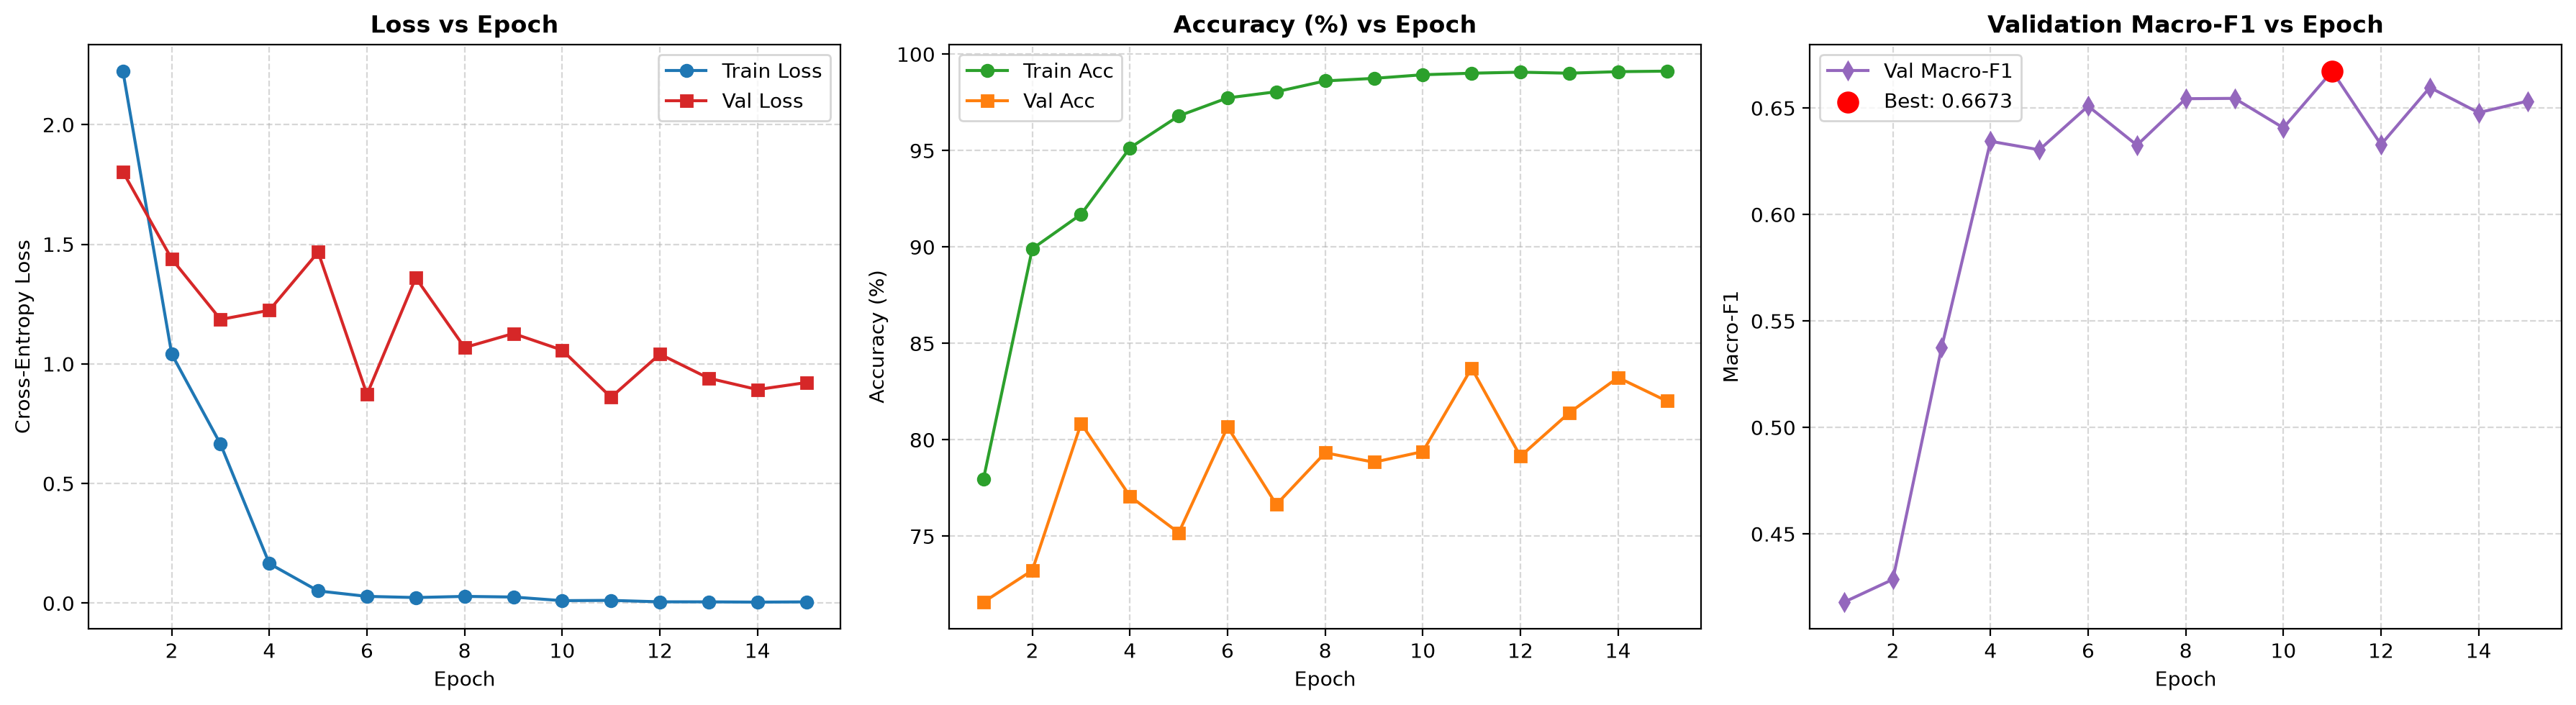

In [5]:
history_path = config.PHASE5A_HISTORIES_DIR / 'training_history.json'
if history_path.is_file():
    with open(history_path, 'r') as f:
        history = json.load(f)
    
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axs = plt.subplots(1, 3, figsize=(18, 5), dpi=200)
    
    # Loss
    axs[0].plot(epochs, history['train_loss'], 'o-', label='Train Loss', color='#1f77b4')
    axs[0].plot(epochs, history['val_loss'], 's-', label='Val Loss', color='#d62728')
    axs[0].set_title('Loss vs Epoch', fontweight='bold')
    axs[0].set_xlabel('Epoch')
    axs[0].set_ylabel('Cross-Entropy Loss')
    axs[0].grid(True, linestyle='--', alpha=0.5)
    axs[0].legend()
    
    # Accuracy
    axs[1].plot(epochs, history['train_acc'], 'o-', label='Train Acc', color='#2ca02c')
    axs[1].plot(epochs, history['val_acc'], 's-', label='Val Acc', color='#ff7f0e')
    axs[1].set_title('Accuracy (%) vs Epoch', fontweight='bold')
    axs[1].set_xlabel('Epoch')
    axs[1].set_ylabel('Accuracy (%)')
    axs[1].grid(True, linestyle='--', alpha=0.5)
    axs[1].legend()
    
    # Macro-F1
    axs[2].plot(epochs, history['val_macro_f1'], 'd-', label='Val Macro-F1', color='#9467bd')
    best_idx = int(np.argmax(history['val_macro_f1']))
    axs[2].scatter([epochs[best_idx]], [history['val_macro_f1'][best_idx]], color='red', s=100, zorder=5, label=f'Best: {history["val_macro_f1"][best_idx]:.4f}')
    axs[2].set_title('Validation Macro-F1 vs Epoch', fontweight='bold')
    axs[2].set_xlabel('Epoch')
    axs[2].set_ylabel('Macro-F1')
    axs[2].grid(True, linestyle='--', alpha=0.5)
    axs[2].legend()
    
    plt.tight_layout()
    plt.show()
else:
    print("Training history not yet generated. Run run_phase5a.py first.")

## 6. Official Test Evaluation & Benchmark Comparison

We inspect the single-run test evaluation results and compare ResNet-50 against the Phase 4B classical ML champion (KNN-4):

In [6]:
comp_csv = config.PHASE5A_METRICS_DIR / 'phase4b_vs_phase5a_comparison.csv'
if comp_csv.is_file():
    comp_df = pd.read_csv(comp_csv)
    print("Phase 4B (Classical ML) vs Phase 5A (ResNet-50 Deep Learning Baseline):")
    display(comp_df)
else:
    print("Comparison CSV not yet generated. Run run_phase5a.py first.")

Phase 4B (Classical ML) vs Phase 5A (ResNet-50 Deep Learning Baseline):


,Model,Input Representation,Val Macro-F1,Val Accuracy (%),Test Macro-F1,Test Accuracy (%),Test Macro Precision,Test Macro Recall,Test Weighted-F1
0,Phase 4B KNN-4 (Classical Champion),"8,186 Handcrafted Features + PCA-100",0.6613,50.85,0.5407,47.20,0.7103,0.5063,0.4386
1,Phase 5A ResNet-50 (Deep Learning Baseline),Raw Pixels (Letterbox 224x224 RGB),0.6673,83.72,0.6631,77.78,0.6886,0.7273,0.7937
